# Figures

In [1]:
import os
import sys

ROOT_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "..", ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.special import zeta as scipy_zeta

In [3]:
plt.rcParams.update({
    "text.usetex"    : False,
    "font.family"    : "serif",
    "font.size"      : 11,
    "axes.titlesize" : 12,
    "figure.dpi"     : 150,
    "savefig.dpi"    : 150,
})

In [4]:
# ── 텍스트 크기 ───────────────────────────────────────────────
FS_LABEL = 9      # 축 레이블: "Real", "Imaginary", "x", "y"
FS_TICK  = 9      # 눈금 레이블
FS_CURVE = 10     # 곡선 레이블: "y = ζ(x)", "y = 1 + 1/2^x"
FS_ANNOT = 8      # 부등식 주석 텍스트

# ── 마커 크기 ─────────────────────────────────────────────────
MS_ARROW = 4      # 축 화살표 마커 (">k", "^k")
MS_POLE  = 6      # 열린 원 마커 — pole / 경계 제외점
MS_POINT = 4      # 점 σ+it 마커

# ── 선 두께 ───────────────────────────────────────────────────
LW_CURVE = 1.5    # 곡선 ζ(x), f_2(x)
LW_TICK  = 0.7    # 눈금 선, 경계선
LW_RED   = 1.5    # 빨간 실수축 선
LW_RED_V = 1.2    # 빨간 수직선

## Figure 1. y = ζ(x)와 y = f₂(x) = 1 + 1/2ˣ의 그래프 비교

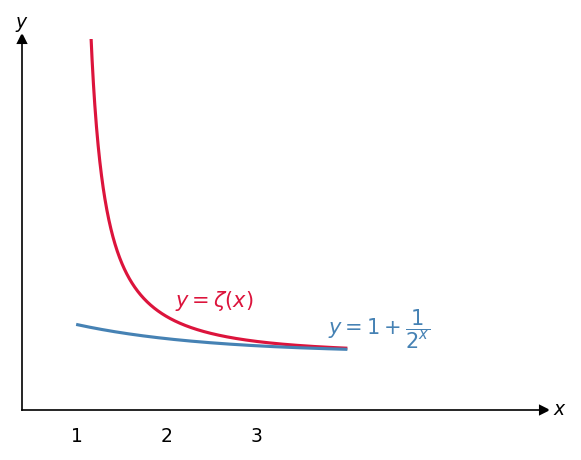

In [39]:
x = np.linspace(1.02, 4.0, 800)

zeta_x = scipy_zeta(x, 1)          # ζ(x) = Σ n^{-x}
f2_x   = 1 + 1 / 2**x              # f_2(x) = 1 + 1/2^x

# ── 레이아웃 설정 ─────────────────────────────────────────────
# x축: 곡선은 x≥1 이후만, y축은 왼쪽 프레임으로 분리
x_data_start = -0.5
x_plot_start = 0.4   # y축 왼쪽 여백
x_plot_end   = 6.2

y_plot_start = 0.0
y_plot_end   = 6.5

fig, ax = plt.subplots(figsize=(4, 3.2))
ax.set_xlim(x_plot_start, x_plot_end)
ax.set_ylim(y_plot_start, y_plot_end)

# ── 곡선 (x ≥ 1 이후만) ──────────────────────────────────────
ax.plot(x, zeta_x, color="crimson",   lw=LW_CURVE)
ax.plot(x, f2_x,   color="steelblue", lw=LW_CURVE)

# ── 축 스타일 ─────────────────────────────────────────────────
# x축: y=0 위치에 실선
ax.spines["bottom"].set_position(("data", 0))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# y축: 데이터와 분리된 왼쪽 끝 (x=x_plot_start)에 고정
ax.spines["left"].set_position(("data", x_plot_start))

# 축 화살표
ax.plot(x_plot_end, 0,           ">k", ms=MS_ARROW, clip_on=False)
ax.plot(x_plot_start, y_plot_end, "^k", ms=MS_ARROW, clip_on=False)

# ── 축 레이블 ─────────────────────────────────────────────────
ax.text(x_plot_end + 0.1, 0,              "$x$",
        va="center", ha="left", fontsize=FS_LABEL)
ax.text(x_plot_start,     y_plot_end + 0.1, "$y$",
        ha="center", va="bottom", fontsize=FS_LABEL)

# ── x=1: 열린 원 + 레이블 ────────────────────────────────────
# ax.plot(1, 0, "o", color="white", ms=MS_POLE,
#         markeredgecolor="black", markeredgewidth=1.0,
#         clip_on=False, zorder=4)
ax.text(1, -0.3, "$1$", ha="center", va="top", fontsize=FS_TICK)
ax.text(2, -0.3, "$2$", ha="center", va="top", fontsize=FS_TICK)
ax.text(3, -0.3, "$3$", ha="center", va="top", fontsize=FS_TICK)

# ── 곡선 인라인 레이블 ────────────────────────────────────────
# ζ(x): 곡선 중간 우측
ax.text(2.1, scipy_zeta(2.1, 1) + 0.25,
        r"$y = \zeta(x)$",
        color="crimson", fontsize=FS_CURVE, ha="left")

# f_2(x): 곡선 우측 끝 근방
ax.text(3.8, 1 + 1/2**3.8 + 0.25,
        r"$y = 1 + \dfrac{1}{2^x}$",
        color="steelblue", fontsize=FS_CURVE, ha="left")

# ── 눈금 제거 ─────────────────────────────────────────────────
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-003-001.png"), bbox_inches="tight")
plt.show()


## Figure 2. Re(s) ≥ 1+a 영역에서의 uniform convergence 증명 구조

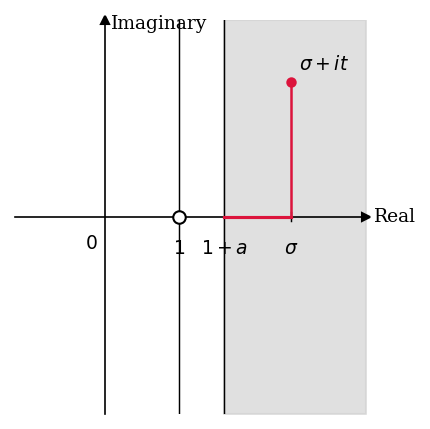

In [27]:
a     = 0.6
sigma = 2.5
t     = 1.5

x_min, x_max = -1.2, 3.5
y_min, y_max = -2.2, 2.2

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# 회색 음영 반평면 Re(s) ≥ 1+a
ax.fill_betweenx([y_min, y_max], 1 + a, x_max,
                 color="lightgray", alpha=0.7, zorder=1)

# 축 스타일
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(x_max, 0,     ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     y_max, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,           "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.08,        y_max - 0.1, "Imaginary", ha="left",   fontsize=FS_LABEL)

# "0" 눈금
ax.text(-0.1, -0.2, "$0$", ha="right", va="top", fontsize=FS_TICK)

# Re(s) = 1 — 검은 실선 + 열린 원 (pole)
ax.plot([1, 1], [y_min, y_max], "k-", lw=LW_TICK, zorder=2)       # ← 추가
ax.plot(1, 0, "o", color="white", ms=MS_POLE,
        markeredgecolor="black", markeredgewidth=1.0, zorder=4)
ax.text(1, -0.25, "$1$", ha="center", va="top", fontsize=FS_TICK)

# "1+a" 경계선
ax.plot([1 + a, 1 + a], [y_min, y_max], "k-", lw=LW_TICK, zorder=2)
ax.text(1 + a, -0.25, r"$1+a$", ha="center", va="top", fontsize=FS_TICK)

# "σ" 눈금
ax.plot([sigma, sigma], [-0.05, 0.05], "k-", lw=LW_TICK)
ax.text(sigma, -0.25, r"$\sigma$", ha="center", va="top", fontsize=FS_TICK)

# 빨간 실수축 선 (1+a → σ)
ax.plot([1 + a, sigma], [0, 0], color="crimson", lw=LW_RED, zorder=3)

# 빨간 수직선 (σ → σ+it)
ax.plot([sigma, sigma], [0, t], color="crimson", lw=LW_RED_V, zorder=3)

# 점 σ+it
ax.plot(sigma, t, "o", color="crimson", ms=MS_POINT, zorder=5)
ax.text(sigma + 0.1, t + 0.1,
        r"$\sigma + it$", ha="left", va="bottom", fontsize=FS_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-003-002.png"), bbox_inches="tight")
plt.show()

## Figure 3. ζ(s)가 analytic한 영역 Re(s) > 1

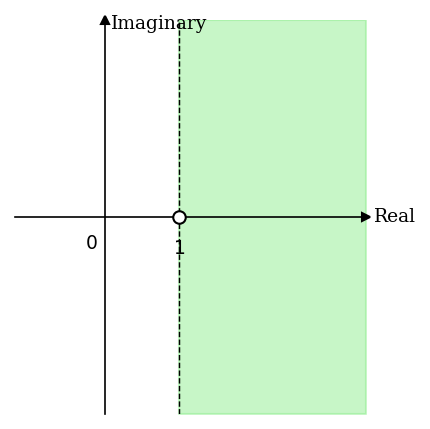

In [7]:
x_min, x_max = -1.2, 3.5
y_min, y_max = -2.2, 2.2

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# 녹색 음영 반평면 Re(s) > 1
ax.fill_betweenx([y_min, y_max], 1, x_max,
                 color="lightgreen", alpha=0.5, zorder=1)

# 축 스타일
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(x_max, 0,     ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     y_max, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,          "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.08,        y_max - 0.1, "Imaginary", ha="left",   fontsize=FS_LABEL)

# "0" 눈금
ax.text(-0.1, -0.2, "$0$", ha="right", va="top", fontsize=FS_TICK)

# Re(s) = 1 경계: 점선 + 열린 원
ax.plot([1, 1], [y_min, y_max], "k--", lw=LW_TICK, zorder=2)
ax.plot(1, 0, "o", color="white", ms=MS_POLE,
        markeredgecolor="black", markeredgewidth=1.0, zorder=4)
ax.text(1, -0.25, "$1$", ha="center", va="top", fontsize=FS_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-003-003.png"), bbox_inches="tight")
plt.show()